# SMS Spam Classification

## Project objective

This notebook refactors the original SMS spam-classification exploration into a concise, reproducible classical NLP workflow. The goal is to compare a small set of sparse TF-IDF text models, select hyperparameters using only cross-validation on the training set, and evaluate the selected model once on a final holdout test split.

Spam is treated as the positive class because missing spam and incorrectly flagging normal messages are the class-specific tradeoffs a reviewer should be able to inspect directly.

## Imports and reproducibility settings

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

src_path = PROJECT_ROOT / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from spam_classifier.data import (
    LABELS,
    POS_LABEL,
    find_conflicting_messages,
    label_counts,
    load_sms_spam_collection,
)
from spam_classifier.evaluation import (
    confusion_matrix_frame,
    error_examples,
    evaluate_classifier,
    prediction_scores,
)
from spam_classifier.modeling import RANDOM_STATE, make_train_test_split, run_model_search

pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", context="notebook")

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "SMSSpamCollection"
IMAGE_DIR = PROJECT_ROOT / "images"
IMAGE_DIR.mkdir(exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Random state: {RANDOM_STATE}")

Project root: /Users/michaelowen/projects/spam-classifier
Random state: 42


## Load and validate the dataset

The workflow expects the UCI SMS Spam Collection raw file at `data/raw/SMSSpamCollection`. Loading validates the required columns, allowed labels, missing messages, exact duplicates, and conflicting labels. The raw message text is preserved for feature extraction.

In [2]:
raw_df = pd.read_csv(
    DATA_PATH,
    sep="	",
    header=None,
    names=["label", "message"],
    dtype={"label": "string", "message": "string"},
    keep_default_na=False,
)

df, report = load_sms_spam_collection(DATA_PATH, return_report=True)

report_table = pd.DataFrame(
    [
        {
            "source_path": report.source_path,
            "loaded_rows": report.loaded_rows,
            "cleaned_rows": report.cleaned_rows,
            "duplicate_label_message_rows_removed": report.duplicate_label_message_rows_removed,
            "missing_message_rows": report.missing_message_rows,
            "conflicting_message_count": report.conflicting_message_count,
        }
    ]
)
display(report_table)
display(df.head())

,source_path,loaded_rows,cleaned_rows,duplicate_label_message_rows_removed,missing_message_rows,conflicting_message_count
0,/Users/michaelowen/projects/spam-classifier/data/raw/SMSSpamCollection,5572,5169,403,0,0


,label,message
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std t...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"


## Class distribution and duplicate analysis

Exact duplicate `label` / `message` rows are removed before splitting so the same labeled text cannot appear in both training and test sets. Messages with conflicting labels are identified separately because they would indicate ambiguous supervision rather than harmless duplication.

,label,count,percent
0,ham,4516,87.4
1,spam,653,12.6


,raw_rows,cleaned_rows,exact_duplicate_rows_removed,message_texts_with_conflicting_labels
0,5572,5169,403,0


No message text appears with conflicting labels.


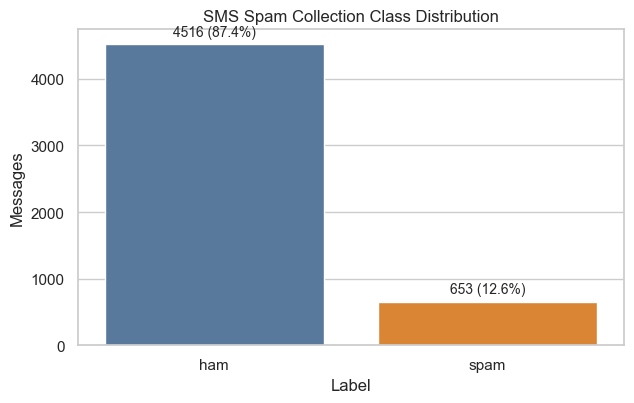

In [3]:
counts = label_counts(df)
counts["percent"] = counts["percent"].mul(100).round(1)
display(counts)

conflicts = find_conflicting_messages(raw_df)
duplicate_summary = pd.DataFrame(
    [
        {
            "raw_rows": len(raw_df),
            "cleaned_rows": len(df),
            "exact_duplicate_rows_removed": report.duplicate_label_message_rows_removed,
            "message_texts_with_conflicting_labels": len(conflicts),
        }
    ]
)
display(duplicate_summary)

if len(conflicts):
    display(conflicts.head(10))
else:
    print("No message text appears with conflicting labels.")

fig, ax = plt.subplots(figsize=(6.5, 4.2))
sns.barplot(data=counts, x="label", y="count", hue="label", palette=["#4C78A8", "#F58518"], legend=False, ax=ax)
for patch, (_, row) in zip(ax.patches, counts.iterrows()):
    ax.annotate(
        f"{row['count']} ({row['percent']:.1f}%)",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 4),
        textcoords="offset points",
    )
ax.set_title("SMS Spam Collection Class Distribution")
ax.set_xlabel("Label")
ax.set_ylabel("Messages")
fig.tight_layout()
fig.savefig(IMAGE_DIR / "class_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

## Evaluation strategy and leakage controls

After the full-dataset loading and duplicate summary, the cleaned data is split once into a stratified 80/20 train/test split. The holdout messages are reserved for final evaluation and are not inspected during label-informed EDA or model selection.

Model selection uses five-fold `StratifiedKFold` on the training set only. Every candidate is a scikit-learn `Pipeline` with `TfidfVectorizer` inside the pipeline, so TF-IDF vocabulary and inverse-document-frequency weights are learned within each cross-validation fold rather than on data outside that fold.

Cross-validation performance and holdout performance are reported separately.

In [4]:
X_train, X_test, y_train, y_test = make_train_test_split(df)

train_df = pd.concat(
    [y_train.rename("label"), X_train.rename("message")],
    axis=1,
).sort_index()

split_summary = pd.DataFrame(
    {
        "split": ["training", "holdout"],
        "use": ["EDA and model selection", "final evaluation only"],
        "rows": [len(train_df), len(X_test)],
    }
)
display(split_summary)

,split,use,rows
0,training,EDA and model selection,4135
1,holdout,final evaluation only,1034


## Exploratory analysis

Label-informed EDA in this section uses only the training data in `train_df`. The holdout messages and labels remain uninspected until the final evaluation section.

character_count             word_count            
                 mean median  max       mean median  max
label                                                   
ham              71.0   53.0  910       14.3   11.0  171
spam            137.7  148.0  223       23.7   25.0   35

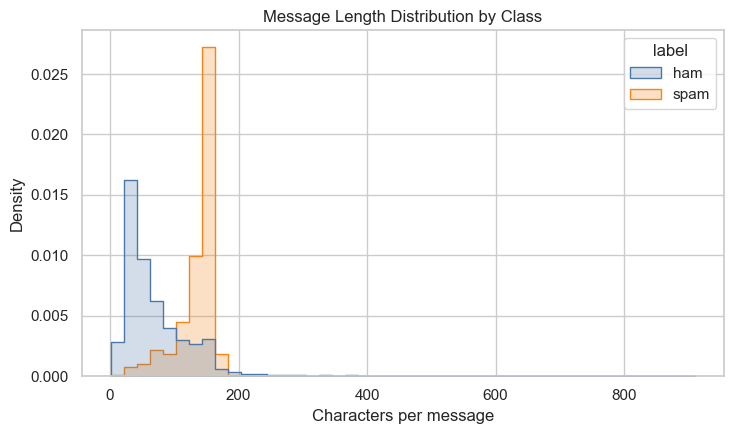

,label,message
0,ham,Ok...
1,ham,How are you holding up?
2,ham,"Fair enough, anything going on?"
3,spam,Free video camera phones with Half Price line rental for 12 mths and 500 cross ntwk mins 100 txts. Call MobileUpd8 0...
4,spam,"Your account has been credited with 500 FREE Text Messages. To activate, just txt the word: CREDIT to No: 80488 T&Cs..."
5,spam,Money i have won wining number 946 wot do i do next


In [5]:
eda = train_df.assign(
    character_count=train_df["message"].str.len(),
    word_count=train_df["message"].str.split().str.len(),
)

length_summary = (
    eda.groupby("label")[["character_count", "word_count"]]
    .agg(["mean", "median", "max"])
    .round(1)
)
display(length_summary)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.histplot(
    data=eda,
    x="character_count",
    hue="label",
    bins=45,
    element="step",
    stat="density",
    common_norm=False,
    palette={"ham": "#4C78A8", "spam": "#F58518"},
    ax=ax,
)
ax.set_title("Message Length Distribution by Class")
ax.set_xlabel("Characters per message")
ax.set_ylabel("Density")
fig.tight_layout()
plt.show()

representative = (
    train_df.groupby("label", group_keys=False)
    .sample(n=3, random_state=RANDOM_STATE)
    .sort_values("label")
    .reset_index(drop=True)
)
display(representative)

In [6]:
def top_terms_for_label(frame, label, n=12):
    messages = frame.loc[frame["label"] == label, "message"]
    vectorizer = CountVectorizer(ngram_range=(1, 2), min_df=2, stop_words=None)
    matrix = vectorizer.fit_transform(messages)
    counts_array = np.asarray(matrix.sum(axis=0)).ravel()
    terms = vectorizer.get_feature_names_out()
    order = counts_array.argsort()[::-1][:n]
    return pd.DataFrame({"label": label, "term": terms[order], "count": counts_array[order]})

term_table = pd.concat(
    [top_terms_for_label(train_df, "ham"), top_terms_for_label(train_df, "spam")],
    ignore_index=True,
)
display(term_table)

,label,term,count
0,ham,you,1506
1,ham,to,1177
2,ham,the,881
3,ham,and,686
4,ham,in,607
5,ham,me,585
6,ham,it,553
7,ham,my,553
8,ham,is,532
9,ham,that,436


## Baseline

In [7]:
comparison, searches = run_model_search(X_train, y_train)

baseline_row = comparison.loc[comparison["model"] == "DummyClassifier"].copy()
metric_cols = [
    "mean_cv_spam_f1",
    "std_cv_spam_f1",
    "mean_cv_spam_precision",
    "mean_cv_spam_recall",
    "mean_cv_balanced_accuracy",
]
baseline_row[metric_cols] = baseline_row[metric_cols].round(3)
baseline_row["best_params"] = baseline_row["best_params"].apply(lambda value: json.dumps(value, sort_keys=True))
display(baseline_row)

,model,mean_cv_spam_f1,std_cv_spam_f1,mean_cv_spam_precision,mean_cv_spam_recall,mean_cv_balanced_accuracy,best_params
3,DummyClassifier,0.0,0.0,0.0,0.0,0.5,"{""tfidf__min_df"": 1, ""tfidf__ngram_range"": [1, 1]}"


## Cross-validated model comparison

,model,mean_cv_spam_f1,std_cv_spam_f1,mean_cv_spam_precision,mean_cv_spam_recall,mean_cv_balanced_accuracy,best_params
0,LinearSVC,0.945,0.008,0.955,0.935,0.964,"{""classifier__C"": 0.5, ""classifier__class_weight"": ""balanced"", ""tfidf__min_df"": 1, ""tfidf__ngram_range"": [1, 2], ""tf..."
1,LogisticRegression,0.937,0.007,0.937,0.937,0.964,"{""classifier__C"": 2.0, ""classifier__class_weight"": ""balanced"", ""tfidf__min_df"": 2, ""tfidf__ngram_range"": [1, 2], ""tf..."
2,MultinomialNB,0.936,0.014,0.989,0.889,0.944,"{""classifier__alpha"": 0.1, ""tfidf__min_df"": 2, ""tfidf__ngram_range"": [1, 2], ""tfidf__stop_words"": null, ""tfidf__subl..."
3,DummyClassifier,0.000,0.000,0.000,0.000,0.500,"{""tfidf__min_df"": 1, ""tfidf__ngram_range"": [1, 1]}"


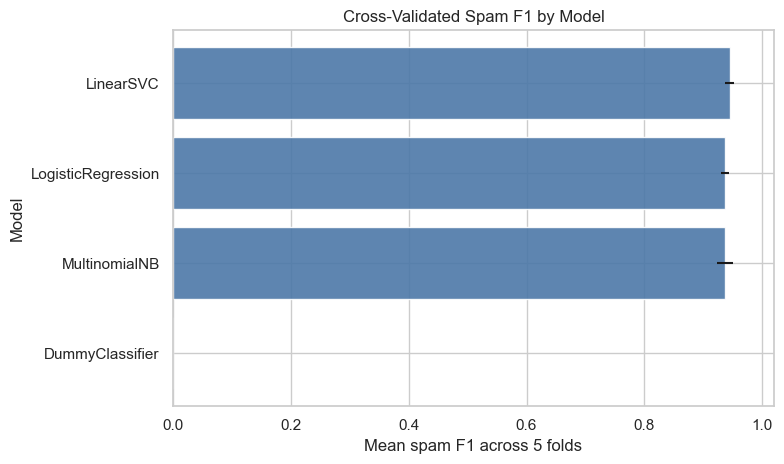

In [8]:
comparison_display = comparison.copy()
comparison_display[metric_cols] = comparison_display[metric_cols].round(3)
comparison_display["best_params"] = comparison_display["best_params"].apply(lambda value: json.dumps(value, sort_keys=True))
display(comparison_display)

plot_data = comparison.sort_values("mean_cv_spam_f1", ascending=True)
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh(
    plot_data["model"],
    plot_data["mean_cv_spam_f1"],
    xerr=plot_data["std_cv_spam_f1"],
    color="#4C78A8",
    alpha=0.9,
)
ax.set_title("Cross-Validated Spam F1 by Model")
ax.set_xlabel("Mean spam F1 across 5 folds")
ax.set_ylabel("Model")
ax.set_xlim(0, 1.02)
fig.tight_layout()
fig.savefig(IMAGE_DIR / "model_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

## Final model selection

The selected model is the candidate with the highest mean cross-validated spam F1 on the training set. `GridSearchCV(refit="spam_f1")` refits the selected pipeline on all training rows after choosing the best hyperparameters.

In [9]:
selected_model_name = comparison.loc[0, "model"]
selected_search = searches[selected_model_name]
final_model = selected_search.best_estimator_

print(f"Selected model: {selected_model_name}")
print("Best parameters:")
print(json.dumps(selected_search.best_params_, indent=2, sort_keys=True))

Selected model: LinearSVC
Best parameters:
{
  "classifier__C": 0.5,
  "classifier__class_weight": "balanced",
  "tfidf__min_df": 1,
  "tfidf__ngram_range": [
    1,
    2
  ],
  "tfidf__stop_words": null,
  "tfidf__sublinear_tf": true
}


## Holdout test evaluation

,selected_model,holdout_spam_precision,holdout_spam_recall,holdout_spam_f1,average_precision,balanced_accuracy,accuracy
0,LinearSVC,0.915,0.908,0.912,0.973,0.948,0.978


              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       903
        spam       0.92      0.91      0.91       131

    accuracy                           0.98      1034
   macro avg       0.95      0.95      0.95      1034
weighted avg       0.98      0.98      0.98      1034



,predicted_ham,predicted_spam
actual_ham,892,11
actual_spam,12,119


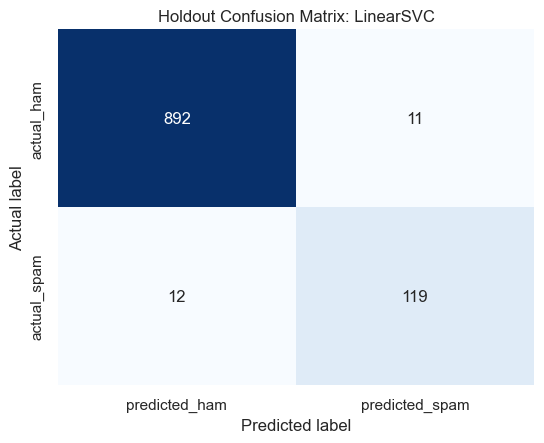

In [10]:
holdout_metrics = evaluate_classifier(final_model, X_test, y_test)

holdout_summary = pd.DataFrame(
    [
        {
            "selected_model": selected_model_name,
            "holdout_spam_precision": holdout_metrics["spam_precision"],
            "holdout_spam_recall": holdout_metrics["spam_recall"],
            "holdout_spam_f1": holdout_metrics["spam_f1"],
            "average_precision": holdout_metrics["average_precision"],
            "balanced_accuracy": holdout_metrics["balanced_accuracy"],
            "accuracy": holdout_metrics["accuracy"],
        }
    ]
).round(3)
display(holdout_summary)

print(classification_report(y_test, final_model.predict(X_test), labels=list(LABELS), zero_division=0))

cm_frame = confusion_matrix_frame(holdout_metrics["confusion_matrix"])
display(cm_frame)

fig, ax = plt.subplots(figsize=(5.6, 4.6))
sns.heatmap(cm_frame, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title(f"Holdout Confusion Matrix: {selected_model_name}")
ax.set_xlabel("Predicted label")
ax.set_ylabel("Actual label")
fig.tight_layout()
fig.savefig(IMAGE_DIR / "confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

## Discriminative terms from the selected model

In [11]:
def selected_model_terms(pipeline, n=15):
    vectorizer = pipeline.named_steps["tfidf"]
    classifier = pipeline.named_steps["classifier"]
    feature_names = vectorizer.get_feature_names_out()

    if hasattr(classifier, "coef_"):
        coefficients = classifier.coef_[0]
        if list(classifier.classes_)[1] != POS_LABEL:
            coefficients = -coefficients
    elif hasattr(classifier, "feature_log_prob_"):
        classes = list(classifier.classes_)
        spam_index = classes.index(POS_LABEL)
        ham_index = classes.index("ham")
        coefficients = classifier.feature_log_prob_[spam_index] - classifier.feature_log_prob_[ham_index]
    else:
        return pd.DataFrame(columns=["spam_indicative_terms", "ham_indicative_terms"])

    spam_order = coefficients.argsort()[::-1][:n]
    ham_order = coefficients.argsort()[:n]
    return pd.DataFrame(
        {
            "spam_indicative_terms": feature_names[spam_order],
            "spam_weight": coefficients[spam_order].round(3),
            "ham_indicative_terms": feature_names[ham_order],
            "ham_weight": coefficients[ham_order].round(3),
        }
    )

terms = selected_model_terms(final_model)
display(terms)

,spam_indicative_terms,spam_weight,ham_indicative_terms,ham_weight
0,call,2.470,my,-1.010
1,txt,2.412,me,-0.991
2,text,2.163,that,-0.830
3,reply,1.927,its,-0.645
4,free,1.855,but,-0.629
5,uk,1.712,at,-0.618
6,www,1.686,it,-0.615
7,mobile,1.599,call me,-0.613
8,com,1.581,gt,-0.612
9,stop,1.540,ok,-0.599


## Error analysis

The table shows up to five false positives and five false negatives from the holdout set. When scores are available, false positives are sorted by the strongest spam-oriented score and false negatives by the weakest spam-oriented score. These examples are useful for inspection, but they are too few to support broad claims about future traffic.

In [12]:
errors = error_examples(final_model, X_test, y_test, limit_per_type=5)
if errors.empty:
    print("No holdout errors to display.")
else:
    display(errors)

,error_type,actual_label,predicted_label,message,score
0,false_positive,ham,spam,I (Career Tel) have added u as a contact on INDYAROCKS.COM to send FREE SMS. To remove from phonebook - sms NO to &...,0.4112
1,false_positive,ham,spam,K k:) sms chat with me.,0.3120
2,false_positive,ham,spam,I'm vivek:)i got call from your number.,0.3111
3,false_positive,ham,spam,I'm at work. Please call,0.1981
4,false_positive,ham,spam,I'm at home. Please call,0.1977
5,false_negative,spam,ham,"In The Simpsons Movie released in July 2007 name the band that died at the start of the film? A-Green Day, B-Blue Da...",-0.8322
6,false_negative,spam,ham,ringtoneking 84484,-0.6734
7,false_negative,spam,ham,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE MINS. INDIA CUST SERVs SED YES. L8ER GOT MEGA BILL. 3 DONT GIV A SHIT....,-0.5008
8,false_negative,spam,ham,"Latest News! Police station toilet stolen, cops have nothing to go on!",-0.4775
9,false_negative,spam,ham,Hi its LUCY Hubby at meetins all day Fri & I will B alone at hotel U fancy cumin over? Pls leave msg 2day 0909972639...,-0.4753


## Example predictions

For the selected `LinearSVC`, positive decision scores favor spam and negative decision scores favor ham; these values are not calibrated probabilities.

In [13]:
examples = pd.DataFrame(
    {
        "message": [
            "Can you call me when you are free?",
            "WIN a free prize now, reply CLAIM to collect",
            "Your appointment is confirmed for tomorrow morning",
            "Urgent! You have been selected for a cash reward",
        ]
    }
)
examples["predicted_label"] = final_model.predict(examples["message"])
example_scores = prediction_scores(final_model, examples["message"])
if example_scores is not None:
    examples["spam_decision_score"] = np.round(example_scores, 4)

display(examples)
print("These are demonstration messages only, not an evaluation set.")

,message,predicted_label,spam_decision_score
0,Can you call me when you are free?,ham,-0.6130
1,"WIN a free prize now, reply CLAIM to collect",spam,1.6798
2,Your appointment is confirmed for tomorrow morning,ham,-0.5396
3,Urgent! You have been selected for a cash reward,spam,0.5949


These are demonstration messages only, not an evaluation set.


## Conclusions and limitations

The final workflow keeps the original SMS spam-classification purpose but replaces the exploratory model loop with a reproducible, leakage-safe evaluation design. Exact duplicate labeled messages are removed before splitting, sparse TF-IDF features are fit inside every candidate pipeline, and the holdout set is used once after model selection.

Important limitations remain: the dataset is historical, relatively small, and may reflect language and geographic biases from its collection context. Spam vocabulary changes over time, so these results should not be assumed to transfer directly to modern messaging traffic without fresh validation.